In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from keras.datasets import imdb

In [4]:
(X_train, y_train), (X_test, y_test)= imdb.load_data(num_words=10000)

In [5]:
data=np.concatenate((X_train,X_test), axis=0)

In [6]:
data.shape

(50000,)

In [7]:
label = np.concatenate((y_train, y_test), axis=0)

In [8]:
X_train.shape

(25000,)

In [9]:
vocab=imdb.get_word_index()

In [10]:
def vectorize(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1

    return results

In [11]:
test_x = data[:10000]
test_y = label[:10000]
train_x = data[10000:]
train_y = label[10000:]


In [12]:
test_x.shape

(10000,)

In [13]:
train_x.shape

(40000,)

In [14]:
print("Categories:", np.unique(label))
print("Number of unique words:",len(np.unique(np.hstack(data))))

Categories: [0 1]
Number of unique words: 9998


<Axes: xlabel='label', ylabel='count'>

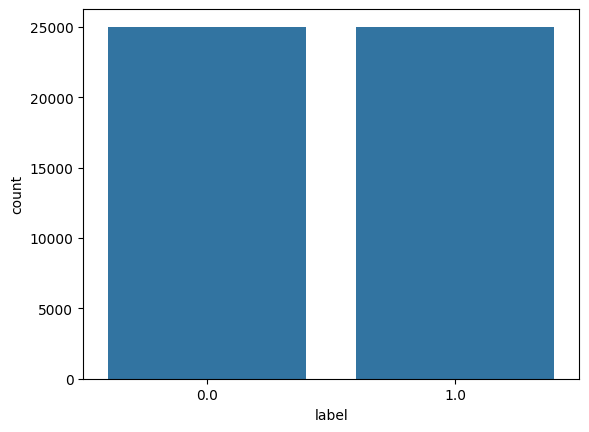

In [15]:
import seaborn as sns # Import seaborn

# Temporary redefinition of vectorize to fix errors for this cell's execution
def vectorize(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for word_index in sequence:
      if word_index < dimension:
        results[i, word_index] = 1
  return results

data = vectorize(data)
label = np.array(label).astype("float32")
labelDF=pd.DataFrame({'label':label})
sns.countplot(x='label', data=labelDF)

In [16]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test = train_test_split(data,label,test_size=0.20,random_state=1)

In [17]:
from keras.utils import to_categorical
from keras import models
from keras import layers

In [18]:
model = models.Sequential()
model.add(layers.Dense(50, activation ="relu", input_shape=(10000,)))
model.add(layers.Dropout(0.3, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation ="relu"))
model.add(layers.Dropout(0.2, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation ="relu"))
model.add(layers.Dense(1, activation ="sigmoid"))

c:\Users\rrbag\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 505,201 (1.93 MB)

 Trainable params: 505,201 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import tensorflow as tf
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

In [21]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [22]:
model = models.Sequential()

In [23]:
model.add(layers.Dense(50, activation ="relu", input_shape=(10000,)))

In [24]:
model.add(layers.Dropout(0.3, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation ="relu"))
model.add(layers.Dropout(0.2, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation ="relu"))

In [25]:
model.add(layers.Dense(1, activation ="sigmoid"))

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 505,201 (1.93 MB)

 Trainable params: 505,201 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8044 - loss: 0.4235 - val_accuracy: 0.5061 - val_loss: 1.5263
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9155 - loss: 0.2191 - val_accuracy: 0.5079 - val_loss: 1.9119
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9425 - loss: 0.1578 - val_accuracy: 0.5035 - val_loss: 2.3520
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9626 - loss: 0.1083 - val_accuracy: 0.5046 - val_loss: 2.9359
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9742 - loss: 0.0761 - val_accuracy: 0.5022 - val_loss: 3.7589
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9810 - loss: 0.0555 - val_accuracy: 0.5037 - val_loss: 3.8976
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9845 - loss: 0.0450 - val_accuracy: 0.5029 - val_loss: 4.6173
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9877 - loss: 0.0351 - val_accuracy: 0.5005 - v

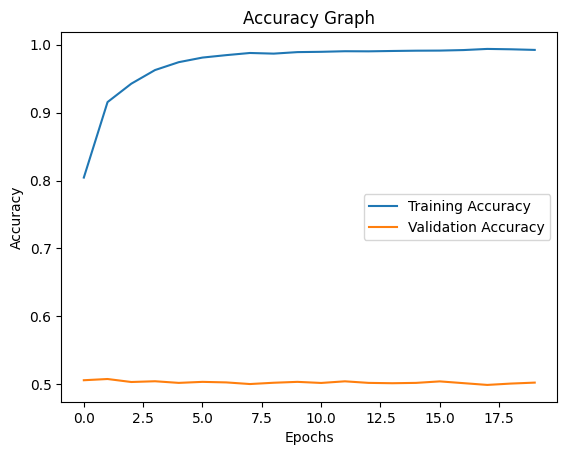

In [29]:
import matplotlib.pyplot as plt
history = model.fit(train_x, train_y, epochs=20, batch_size=512, validation_data=(test_x, test_y), callbacks=[callback])
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()